In [37]:
import os, sys
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import sklvq
from sklearn.metrics import root_mean_squared_error as rmse
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
parts=os.getcwd().split('/')
print(parts)
if (parts[-1]=='scripts') |(parts[-1]=='notebooks'):
    parts=parts[:-1]
code_path='/'.join(parts)+'/scripts/'
sys.path.append(code_path)
out_path='/'.join(parts)+'/results/metaanalysis/'
solver_type='sgd'
figpath='/'.join(parts)+'/figures/'
exp_type='random'
dname_all=['diabetes', 'surgical', 'banking', 'adult', 'criteo','breastcancer']
dname=dname_all[3]
metapath='%s%s/%s_%s_summary.csv'%(out_path,solver_type, dname, exp_type)
meta_df=pd.read_csv(metapath, sep='\t')
print(metapath)
solver_meta_df=meta_df.loc[(meta_df['solver_type']==solver_type)]
print(solver_meta_df.shape)
flag=solver_meta_df[['nan_un_loss_frac_M1', 'nan_un_retain_frac_M2']].sum().sum()
#print(solver_meta_df.columns)
############ color and marker specs ##################
fs, lw,ms, mew=8, 0.5, 4, 0.5
lcolor, mfc, alpha=['r','g','b'], ['none',''], [1, 0.75, 0.6]
linestyle, marker=['--', ':'], ['d','o','s']
patch1 = mpatches.Patch(color='r', label='ppc=1')
patch2 = mpatches.Patch(color='g', label='ppc=2')  
patch3 = mpatches.Patch(color='b', label='ppc=3')
M1_line = mlines.Line2D([], [], color='k', marker=marker[0], mfc='none', mec='k', markersize=ms+1, linestyle=linestyle[0],label='M1')
M2_line = mlines.Line2D([], [], color='k', marker=marker[1], mfc='none', mec='k', markersize=ms+1, linestyle=linestyle[1],label='M2')
#handleorder1=[patch1, patch2, patch3, M1_line, M2_line]
#handleorder2=[patch1, M1_line, patch2, M2_line, patch3]
handleorder1=[patch1, patch2, M1_line, M2_line]
handleorder2=[patch1, M1_line, patch2, M2_line]
#########################################
flag
#solver_meta_df

['', 'mnt', 'nvme1n1p2', 'codes_datasets', 'toolboxes', 'unlearn-lvq', 'notebooks']
/mnt/nvme1n1p2/codes_datasets/toolboxes/unlearn-lvq/results/metaanalysis/sgd/adult_random_summary.csv
(18, 81)


0

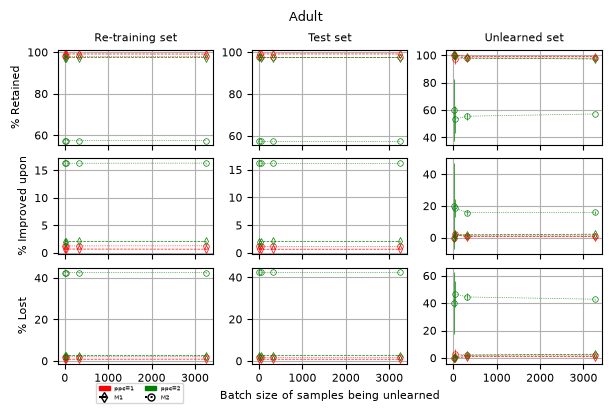

In [4]:
panel_col_dict={'tr': 'Re-training set', 'te': 'Test set', 'un': 'Unlearned set'}
vert_panel_col_dict={'retain frac': '% Retained', 'loss frac': '% Lost', 'gain frac': '% Improved upon'}

fig0, ax0= plt.subplots(nrows=3, ncols=3, sharex=True, figsize=(6,4), layout="constrained")

for i in np.sort(solver_meta_df['prot_per_class'].unique()):
    dummy_df=solver_meta_df.loc[(solver_meta_df['prot_per_class']==i)].copy()#devs=['mean_dev_M0%s'%model, 'mean_dev_M0%s'%model] 
    lc=lcolor[i-1]
    for sidx, subset in enumerate(['tr','te', 'un']):
        c=1
        measures=['n_unlearned', 
                  'mean_%s_retain_frac_M1'%(subset), 'std_%s_retain_frac_M1'%(subset),
                  'mean_%s_gain_frac_M1'%(subset), 'std_%s_gain_frac_M1'%(subset),
                  'mean_%s_loss_frac_M1'%(subset), 'std_%s_loss_frac_M1'%(subset),
                  'mean_%s_retain_frac_M2'%(subset), 'std_%s_retain_frac_M2'%(subset),
                  'mean_%s_gain_frac_M2'%(subset), 'std_%s_gain_frac_M2'%(subset),
                  'mean_%s_loss_frac_M2'%(subset), 'std_%s_loss_frac_M2'%(subset)]
        for midx, model in enumerate(['M1', 'M2']):#  print(subset, model, i)
            m=marker[midx]
            temp_df=dummy_df[measures].copy()#  meas_df=temp_df[measures].copy()
            if dname=='criteo':
                ax0[0, sidx].errorbar(np.log(temp_df['n_unlearned']), temp_df[measures[c]], yerr=temp_df[measures[c+1]], color=lc, #capsize=5,
                 marker=m, ls=linestyle[midx],mew=mew, lw=lw, ms=ms, mec=lc,mfc='none',label='%s: %d ppc'%(model,i), alpha=alpha[i-1])
                ax0[0,sidx].set_ylim([99.4,100.2])
         #   elif dname=='banking':
         #       ax0[0, sidx].errorbar(temp_df['n_unlearned'], temp_df[measures[c]], yerr=temp_df[measures[c+1]], color=lc, #capsize=5,
         #        marker=m, ls=linestyle[midx],mew=mew, lw=lw, ms=ms, mec=lc,mfc='none',label='%s: %d ppc'%(model,i),alpha=alpha[i-1]) 
         #       ax0[0,sidx].set_ylim([99.7,100.4])
            else:
                ax0[0, sidx].errorbar(temp_df['n_unlearned'], temp_df[measures[c]], yerr=temp_df[measures[c+1]], color=lc, #capsize=5,
                 marker=m, ls=linestyle[midx],mew=mew, lw=lw, ms=ms, mec=lc,mfc='none',label='%s: %d ppc'%(model,i)) #,alpha=alpha[i-1])
            #    ax0[0, sidx].errorbar(temp_df['n_unlearned'], temp_df[measures[c]], yerr=temp_df[measures[c+1]], color=lc, #capsize=5,
            #     marker=m, ls=linestyle[midx],mew=mew, lw=lw, ms=ms, mec=lc,mfc='none',label='%s: %d ppc'%(model,i))
            if (i==1) & (midx==0):
                colname_parts=measures[c].split('_')[1:-1]
                if sidx==0:
                    ax0[0,sidx].set_ylabel(vert_panel_col_dict[' '.join(colname_parts[1:])], fontsize=fs)
                ax0[0,sidx].set_title(panel_col_dict[colname_parts[0]], fontsize=fs)
            c+=2
            if dname=='criteo':
                ax0[1, sidx].errorbar(np.log(temp_df['n_unlearned']), temp_df[measures[c]],yerr=temp_df[measures[c+1]],color=lc,
                    marker=m, ls=linestyle[midx],mew=mew, lw=lw, ms=ms, mec=lc,mfc='none',label='%s: %d ppc'%(model,i), alpha=alpha[i-1])
                ax0[1,sidx].set_ylim([-5,5])
        #    elif dname=='adult':
        #        ax0[1, sidx].errorbar(temp_df['n_unlearned'], temp_df[measures[c]],yerr=temp_df[measures[c+1]],color=lc,
        #            marker=m, ls=linestyle[midx],mew=mew, lw=lw, ms=ms, mec=lc,mfc='none',label='%s: %d ppc'%(model,i))
        #        ax0[1,sidx].set_ylim([-0.1,3])
            else:               
                ax0[1, sidx].errorbar(temp_df['n_unlearned'], temp_df[measures[c]],yerr=temp_df[measures[c+1]],color=lc,
                    marker=m, ls=linestyle[midx],mew=mew, lw=lw, ms=ms, mec=lc,mfc='none',label='%s: %d ppc'%(model,i))#,
                                      #alpha=alpha[i-1])
            if (i==1) & (midx==0) & (sidx==0):
                colname_parts=measures[c].split('_')[2:-1]
                ax0[1,sidx].set_ylabel(vert_panel_col_dict[' '.join(colname_parts)], fontsize=fs)
            c+=2
            if dname=='criteo':
                ax0[2, sidx].errorbar(np.log(temp_df['n_unlearned']), temp_df[measures[c]],yerr=temp_df[measures[c+1]],color=lc,
                    marker=m, ls=linestyle[midx],mew=mew, lw=lw, ms=ms, mec=lc,mfc='none',label='%s: %d ppc'%(model,i), alpha=alpha[i-1])
                ax0[2,sidx].set_ylim([-0.05,0.05])
            else:
                ax0[2, sidx].errorbar(temp_df['n_unlearned'], temp_df[measures[c]],yerr=temp_df[measures[c+1]],color=lc,
                    marker=m, ls=linestyle[midx],mew=mew, lw=lw, ms=ms, mec=lc,mfc='none',label='%s: %d ppc'%(model,i))
            if (i==1) & (midx==0) & (sidx==0):
                colname_parts=measures[c].split('_')[2:-1]
                ax0[2,sidx].set_ylabel(vert_panel_col_dict[' '.join(colname_parts)], fontsize=fs)
            if (i==1) & (midx==1) & (sidx==1):
                colname_parts=measures[c].split('_')[2:-1]
                if dname=='criteo':
                    ax0[2,sidx].set_xlabel("Batch size of samples being unlearned\n (in log scale)", fontsize=fs)
                else:
                    ax0[2,sidx].set_xlabel("Batch size of samples being unlearned", fontsize=fs)
            c+=2#  ax0[2,sidx].set_yscale('linear')
            ax0[0, sidx].tick_params(axis='both', which='both', labelsize=fs)           
            ax0[1, sidx].tick_params(axis='both', which='both', labelsize=fs)
            ax0[2, sidx].tick_params(axis='both', which='both', labelsize=fs)
ax0[0, 0].grid()
ax0[0, 1].grid()
ax0[0, 2].grid()
ax0[1, 0].grid()
ax0[1, 1].grid()
ax0[1, 2].grid()
ax0[2, 0].grid()
ax0[2, 1].grid()
ax0[2, 2].grid()
handles, labels = ax0[0,0].get_legend_handles_labels()
#fig0.legend(handles, labels, loc='lower center', ncols=6, prop={"size":8})
if dname=='criteo':
    fig0.legend(handles=handleorder2, loc='lower right', ncols=3, prop={"size":5},
           bbox_to_anchor=(0.3, 0))
else:
    fig0.legend(handles=handleorder2, loc='lower right', ncols=2, prop={"size":4},
           bbox_to_anchor=(0.3, 0))
fig0.suptitle(dname.capitalize(), fontsize=fs+1)
fig0.savefig('%sperf_swish_wrt_M0_%s_%s1.pdf'%(figpath, dname, solver_type), dpi=100, bbox_inches="tight", pad_inches=0.01)

In [4]:
solver_meta_df[['mean_te_Acc_M0', 'mean_te_Acc_M1', 'mean_te_Acc_M2']]#.columns#[['mean_tr_Acc']]

,mean_te_Acc_M0,mean_te_Acc_M1,mean_te_Acc_M2
0,0.792949,0.791413,0.785763
1,0.795344,0.791266,0.588539
2,0.792949,0.791413,0.785763
3,0.795344,0.791192,0.588539
4,0.792949,0.791426,0.785763
5,0.795344,0.791094,0.588539
6,0.792949,0.791462,0.785763
7,0.795344,0.791217,0.588539


### Speed-up factor

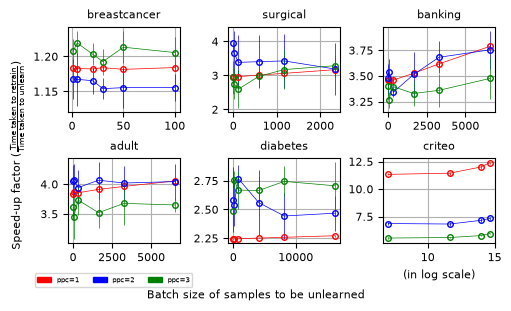

In [2]:

dname_all=['breastcancer', 'surgical', 'banking', 'adult', 'criteo', 'diabetes']
row_col_map={'breastcancer':[0,0],'surgical':[0,1],'banking':[0,2], 'adult':[1,0],'diabetes':[1,1], 
             'criteo':[1,2]}
fs, lw, ms=8, 0.5, 4
lcolor=['r','b','g']
fig2, ax2= plt.subplots(nrows=2, ncols=int(len(dname_all)/2),figsize=(5,3), dpi=100, layout="constrained")

for dname in dname_all:
    metapath='%s%s/%s_%s_summary.csv'%(out_path,solver_type, dname, exp_type)
    meta_df=pd.read_csv(metapath, sep='\t')
    solver_meta_df=meta_df.loc[(meta_df['solver_type']==solver_type)]
    for i in np.sort(meta_df['prot_per_class'].unique()):
       # print(dname, i)
        prot_meta_df=meta_df.loc[(meta_df['prot_per_class']==i) & (meta_df['solver_type']==solver_type)]
        nrow, ncol=row_col_map[dname][0],row_col_map[dname][1] 
        if dname=='criteo':
            h=ax2[nrow, ncol].errorbar(np.log(prot_meta_df['n_unlearned'].to_numpy()), prot_meta_df['mean_dev_M1M2'].to_numpy(),
                yerr=prot_meta_df['std_dev_M1M2'].to_numpy(), marker='o', mfc='none', mec=lcolor[i-1], 
                lw=lw, ms=ms, ecolor=lcolor[i-1],c=lcolor[i-1],  label='nProt=%d'%i)
        else:
            h=ax2[nrow, ncol].errorbar(prot_meta_df['n_unlearned'].to_numpy(), prot_meta_df['mean_dev_M1M2'].to_numpy(),
                yerr=prot_meta_df['std_dev_M1M2'].to_numpy(), marker='o', mfc='none', mec=lcolor[i-1], 
                lw=lw, ms=ms, ecolor=lcolor[i-1],c=lcolor[i-1],  label='nProt=%d'%i)
    ax2[nrow, ncol].grid()
    ax2[nrow, ncol].tick_params(axis='both', which='major', labelsize=fs)
    ax2[nrow, ncol].set_title(dname, fontsize=fs)
    if dname=='criteo':
        ax2[nrow, ncol].set_xlabel('(in log scale)', fontsize=fs)
        #ax0[i-1].errorbar(prot_meta_df['n_unlearned'].to_numpy(), prot_meta_df['mean_speedupX'].to_numpy(),
        #           yerr=prot_meta_df['std_speedupX'].to_numpy(), fmt='-o', lw=lw, ms=5)
patch1 = mpatches.Patch(color='r', label='ppc=1')
patch2 = mpatches.Patch(color='b', label='ppc=2')  
patch3 = mpatches.Patch(color='g', label='ppc=3')
handleorder1=[patch1, patch2, patch3]
handleorder2=[patch1, M1_line, patch2, M2_line, patch3]
fig2.legend(handles=handleorder1, loc='lower right', ncols=5, prop={"size":5},
           bbox_to_anchor=(0.38, 0.05))
fig2.supxlabel('Batch size of samples to be unlearned', fontsize=fs)
fig2.supylabel(r'Speed-up factor ($\frac{\text{Time taken to retrain}}{\text{Time taken to unlearn}}$)', fontsize=fs)

fig2.savefig('%sspeedup_%s.pdf'%(figpath, solver_type), dpi=100, bbox_inches="tight", pad_inches=0.01)

### Deviation from M1 and M2

breastcancer [  1   5  20  30  50 100]
surgical [   2   12  118  586 1171 2342]
banking [   4   33  330 1648 3295 6590]
adult [   4   33  326 1629 3257 6513]
criteo [   1147  114633 1146327 2292653]
diabetes [    9    82   815  4071  8142 16283]


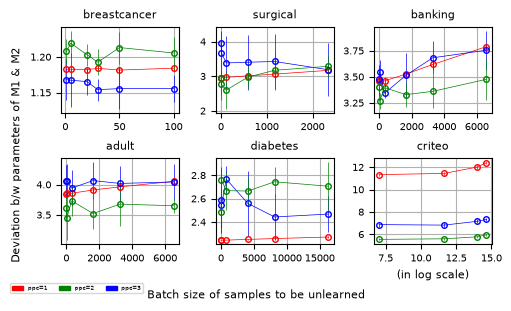

In [12]:
ftrs=['mean_dev_M0M2','std_dev_M0M2', 'mean_dev_M1M2', 'std_dev_M1M2']

dname_all=['breastcancer', 'surgical', 'banking', 'adult', 'criteo', 'diabetes']
row_col_map={'breastcancer':[0,0],'surgical':[0,1],'banking':[0,2], 'adult':[1,0],'diabetes':[1,1], 
             'criteo':[1,2]}
fs, lw, ms=8, 0.5, 4
lcolor=['r','b','g']
fig3, ax3= plt.subplots(nrows=2, ncols=int(len(dname_all)/2),figsize=(5,3), dpi=100, layout="constrained")

for dname in dname_all:
    metapath='%s%s/%s_%s_summary.csv'%(out_path,solver_type, dname, exp_type)
    meta_df=pd.read_csv(metapath, sep='\t')
    solver_meta_df=meta_df.loc[(meta_df['solver_type']==solver_type)]
    print(dname, solver_meta_df['n_unlearned'].unique())
    for i in np.sort(meta_df['prot_per_class'].unique()):
        prot_meta_df=meta_df.loc[(meta_df['prot_per_class']==i) & (meta_df['solver_type']==solver_type)]
        nrow, ncol=row_col_map[dname][0],row_col_map[dname][1]
       # print(dname, i)
        if dname=='criteo':
            h=ax3[nrow, ncol].errorbar(np.log(prot_meta_df['n_unlearned'].to_numpy()), prot_meta_df['mean_dev_M1M2'].to_numpy(),
                yerr=prot_meta_df['std_dev_M1M2'].to_numpy(), marker='o', mfc='none', mec=lcolor[i-1], 
                lw=lw, ms=ms, ecolor=lcolor[i-1],c=lcolor[i-1],  label='nProt=%d'%i)
        else:
            h=ax3[nrow, ncol].errorbar(prot_meta_df['n_unlearned'].to_numpy(), prot_meta_df['mean_dev_M1M2'].to_numpy(),
                yerr=prot_meta_df['std_dev_M1M2'].to_numpy(), marker='o', mfc='none', mec=lcolor[i-1], 
                lw=lw, ms=ms, ecolor=lcolor[i-1],c=lcolor[i-1],  label='nProt=%d'%i)
    ax3[nrow, ncol].grid()
    ax3[nrow, ncol].tick_params(axis='both', which='major', labelsize=fs-1)
    ax3[nrow, ncol].set_title(dname, fontsize=fs)
    if dname=='criteo':
        ax3[nrow, ncol].set_xlabel('(in log scale)', fontsize=fs)
        #ax0[i-1].errorbar(prot_meta_df['n_unlearned'].to_numpy(), prot_meta_df['mean_speedupX'].to_numpy(),
        #           yerr=prot_meta_df['std_speedupX'].to_numpy(), fmt='-o', lw=lw, ms=5)
handleorder1=[patch1, patch2, patch3]
handleorder2=[patch1, M1_line, patch2, M2_line, patch3]
fig3.legend(handles=handleorder1, loc='lower right', ncols=3, prop={"size":4},
           bbox_to_anchor=(0.28, 0.03))
fig3.supxlabel('Batch size of samples to be unlearned', fontsize=fs)
fig3.supylabel('Deviation b/w parameters of M1 & M2', fontsize=fs)
fig3.savefig('%sdeviationM1M2_%s.pdf'%(figpath, solver_type), dpi=100, bbox_inches="tight", pad_inches=0.01)
#fig2.supylabel(r'Speed-up factor ($\frac{\text{Time to retrain}}{\text{Time to unlearn}}$)', fontsize=fs)

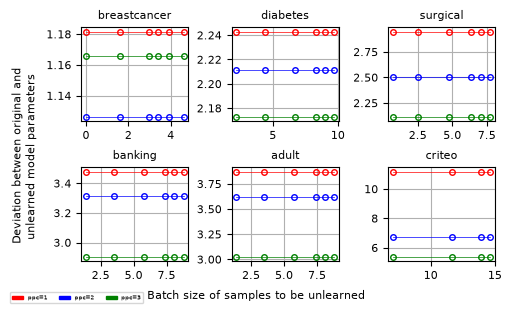

In [22]:
ftrs=['mean_dev_M0M2','std_dev_M0M2', 'mean_dev_M1M2', 'std_dev_M1M2']

dname_all=['diabetes', 'surgical', 'banking', 'adult', 'criteo','breastcancer']
row_col_map={'breastcancer':[0,0],'diabetes':[0,1], 'surgical':[0,2], 'banking':[1,0], 'adult':[1,1],
             'criteo':[1,2]}
fs, lw, ms=8, 0.5, 4
lcolor=['r','b','g']
fig4, ax4= plt.subplots(nrows=2, ncols=int(len(dname_all)/2),figsize=(5,3), dpi=100, layout="constrained")

for dname in dname_all:
    metapath='%s%s/%s_%s_summary.csv'%(out_path,solver_type, dname, exp_type)
    meta_df=pd.read_csv(metapath, sep='\t')
    solver_meta_df=meta_df.loc[(meta_df['solver_type']==solver_type)]
    for i in np.sort(meta_df['prot_per_class'].unique()):
       # print(dname, i)
        prot_meta_df=meta_df.loc[(meta_df['prot_per_class']==i) & (meta_df['solver_type']==solver_type)]
        nrow, ncol=row_col_map[dname][0],row_col_map[dname][1] 
        h=ax4[nrow, ncol].errorbar(np.log(prot_meta_df['n_unlearned'].to_numpy()), prot_meta_df['mean_dev_M0M2'].to_numpy(),
                yerr=prot_meta_df['std_dev_M0M2'].to_numpy(), marker='o', mfc='none', mec=lcolor[i-1], 
                lw=lw, ms=ms, ecolor=lcolor[i-1],c=lcolor[i-1],  label='nProt=%d'%i)
    ax4[nrow, ncol].grid()
    ax4[nrow, ncol].tick_params(axis='both', which='major', labelsize=fs)
    ax4[nrow, ncol].set_title(dname, fontsize=fs)
    if dname=='criteo':
        ax2[nrow, ncol].set_xlabel('(in log scale)', fontsize=fs)
        #ax0[i-1].errorbar(prot_meta_df['n_unlearned'].to_numpy(), prot_meta_df['mean_speedupX'].to_numpy(),
        #           yerr=prot_meta_df['std_speedupX'].to_numpy(), fmt='-o', lw=lw, ms=5)
handleorder1=[patch1, patch2, patch3]
handleorder2=[patch1, M1_line, patch2, M2_line, patch3]
fig4.legend(handles=handleorder1, loc='lower right', ncols=5, prop={"size":4},
           bbox_to_anchor=(0.28, 0))
fig4.supxlabel('Batch size of samples to be unlearned', fontsize=fs)
fig4.supylabel('Deviation between original and\n unlearned model parameters', fontsize=fs)
fig4.savefig('%sdeviationM0M2_%s_%s.pdf'%(figpath, solver_type), dpi=100, bbox_inches="tight", pad_inches=0.01)

In [12]:
from collections import Counter
#sys.path.append(code_path)
from experiment_utils import dataset_health
for dname in dname_all:
    Xtrain, Ytrain, Xtest, Ytest, features=dataset_health(dname)
    dt_dict={'Dataset name':dname.capitalize(), 'Num training': len(Ytrain), 'Num test': len(Ytest),
             'Class imbalance': np.sum(Ytrain==0)/np.sum(Ytrain==1), 
            'Num. features': len(features)}
    temp_df=pd.DataFrame.from_dict(data=dt_dict, orient='index').T
    if dname==dname_all[0]:
        data_char_df=temp_df.copy()
    else:
        data_char_df=pd.concat([data_char_df, temp_df])
data_char_df.to_csv('%sdataset_characteristics.csv'%(out_path), sep='\t', index=False)

In [17]:
print(out_path)
modelpath='/'.join(parts)+'/models/'
nprots_per_class=3
picklefilename='%s%s/%s_random_%s_nprot%d0.pkl'%(modelpath, dname, dname, solver_type, nprots_per_class)
with open(picklefilename, 'rb') as file:
    model_sets=pickle.load(file)
    retrained_all, unlearned_all=model_sets['retrained'], model_sets['unlearned']
    M0=model_sets['original']
print(picklefilename, M0.prototypes_.shape)

/mnt/nvme1n1p2/codes_datasets/toolboxes/unlearn-lvq/results/metaanalysis/
/mnt/nvme1n1p2/codes_datasets/toolboxes/unlearn-lvq/models/diabetes/diabetes_random_sgd_nprot30.pkl (6, 38)


In [20]:
metapath='%s%s/%s_%s_dist_presd_nprot_%d.csv'%(out_path,solver_type, dname, exp_type, nprots_per_class)
print(metapath)
dist_perf_df=pd.read_csv(metapath, sep='\t')
print(dist_perf_df.columns)
dist_perf_df.head(5)

/mnt/nvme1n1p2/codes_datasets/toolboxes/unlearn-lvq/results/metaanalysis/sgd/diabetes_random_dist_presd_nprot_3.csv
Index([',solver_type,iter,n_unlearned,unlearn_indices,Yunlearn_gt,Yunlearn_M0,Yunlearn_M1,Yunlearn_M2,M0_dist_prot_0,M0_dist_prot_1,M0_dist_prot_2,M0_dist_prot_3,M0_dist_prot_4,M0_dist_prot_5,M1_dist_prot_0,M1_dist_prot_1,M1_dist_prot_2,M1_dist_prot_3,M1_dist_prot_4,M1_dist_prot_5,M1_dist_prot_0,M1_dist_prot_1,M1_dist_prot_2,M1_dist_prot_3,M1_dist_prot_4,M1_dist_prot_5'], dtype='str')


,",solver_type,iter,n_unlearned,unlearn_indices,Yunlearn_gt,Yunlearn_M0,Yunlearn_M1,Yunlearn_M2,M0_dist_prot_0,M0_dist_prot_1,M0_dist_prot_2,M0_dist_prot_3,M0_dist_prot_4,M0_dist_prot_5,M1_dist_prot_0,M1_dist_prot_1,M1_dist_prot_2,M1_dist_prot_3,M1_dist_prot_4,M1_dist_prot_5,M1_dist_prot_0,M1_dist_prot_1,M1_dist_prot_2,M1_dist_prot_3,M1_dist_prot_4,M1_dist_prot_5"
0,"0,sgd,0.0,16283.0,48732,0.0,0.0,0.0,0.0,336.12..."
1,"1,sgd,0.0,16283.0,10340,1.0,1.0,1.0,1.0,632.59..."
2,"2,sgd,0.0,16283.0,44710,1.0,0.0,0.0,0.0,430.06..."
3,"3,sgd,0.0,16283.0,37798,0.0,0.0,0.0,0.0,159.77..."
4,"4,sgd,0.0,16283.0,14500,0.0,0.0,0.0,0.0,253.27..."


In [55]:
import sklvq
from experiment_utils import dataset_health
from experiment_utils import data_norm_log
from unlearning.unlearn_eval import *
modelpath='/'.join(parts)+'/models/'
dname, solver_type='breastcancer', 'sgd'
nprots_per_class=1
#picklefilename='%s%s/%s_random_%s_nprot%d0.pkl'%(modelpath, dname, dname, solver_type, nprots_per_class)
picklefilename='%s%s/%s_random_unlearn_enforce_%s_nprot%d.pkl'%(modelpath, dname, dname, solver_type, nprots_per_class)
metapath='%s%s/%s_%s_dist_presd_nprot_%d.csv'%(out_path,solver_type, dname, exp_type, nprots_per_class)
with open(picklefilename, 'rb') as file:
    model_sets=pickle.load(file)
retrained_all, unlearned_all=model_sets['retrained'], model_sets['unlearned']
M0=model_sets['original']
Xtrain, Ytrain, Xtest, Ytest, features=dataset_health(dname)
zXtrain, zXtest=data_norm_log(Xtrain[features], Xtest[features])
nopts, iter=2, 0
M1, M2=retrained_all[1]['models'][iter]['model'], unlearned_all[1]['models'][iter]['model']
print(list(unlearned_all.keys()))
n=unlearned_all[nopts]['n']
print(n, unlearned_all[nopts]['n'])
unlearn_indices=unlearned_all[nopts]['models'][iter]['unlearn_indices']
zXunlearn, Yunlearn=zXtrain.iloc[unlearn_indices], Ytrain[unlearn_indices]
est_unlearn_M0, est_unlearn_M1, est_unlearn_M2=M0.predict(zXunlearn), M1.predict(zXunlearn), M2.predict(zXunlearn)
#M1, M2=retrained_all[nopts]['models'][iter]['model'], unlearned_all[nopts]['models'][iter]['model']

TypeError: 'GLVQ' object is not subscriptable

In [65]:
print(unlearned_all[0]['models'][1].prototypes_[0])
print(unlearned_all[0]['models'][2].prototypes_[0])
unlearned_all[0].keys()

[ 2.94382348  3.10320797  4.77842756  6.79676588 -2.20346246 -1.65747711
 -0.95049211 -1.57786652 -1.57151161 -2.81141052 -0.27679653  0.21801572
  1.52765604  4.11401291 -5.18754328 -3.37630055 -2.86212421 -4.0907131
 -4.11112848 -5.58918551  3.12512252  3.38206733  4.96209467  6.98350583
 -1.84625948 -0.77831375 -0.33015137 -1.26934398 -1.05136328 -2.38050392]
[-1.41862373e-01 -1.06047470e-01 -2.56189653e-01 -7.22228268e-01
 -2.96211597e-02 -1.52180315e-03  2.06324886e-01  2.95314512e-01
 -8.50816956e-03 -6.09098587e-02  1.01308820e-01  1.45035394e-04
 -6.22518970e-02 -4.57510672e-01  1.36415871e-03 -7.08141531e-02
  5.71550935e-02 -2.96202907e-02 -3.24780407e-02 -3.13253831e-01
 -1.80612278e-01 -1.36375924e-01 -3.16952612e-01 -8.97423866e-01
  7.67094655e-03  2.50375178e-02  1.02014375e-01  1.55218999e-01
  2.23752982e-02 -3.29576530e-02]


dict_keys(['n', 'models'])

In [14]:
from collections import Counter
zXtrain.shape
print(Counter(Ytrain), Counter(Ytrain[unlearn_indices]))

Counter({0: 24720, 1: 7841}) Counter({0: 241, 1: 85})


In [49]:
print(unlearned_all[3]['models'][0]['model'].prototypes_[0])
print(unlearned_all[0]['models'][1]['model'].prototypes_[0])

[  4.34391932  -5.49170879  -0.27815355   2.68963852  -2.61652958
  14.96170272 -14.1449371    4.44992501  -1.24021366  -2.2222605 ]
[  4.34391932  -5.49170879  -0.27815355   2.68963852  -2.61652958
  14.96170272 -14.1449371    4.44992501  -1.24021366  -2.2222605 ]


In [53]:
import copy
Mz=copy.copy(M0)
M0.prototypes_[0]

array([ 3.41720685, -4.06617035, -0.22079652,  2.1215171 , -2.00173056,
       11.98378178, -9.75062723,  3.50538403, -0.97616637, -2.20131008])

In [107]:
Xtrain['capital-gain']=Xtrain['capital-gain'].astype('float64')
cgain=Xtrain['capital-gain'].values.copy()#to_numpy()
cgain[np.where(cgain<=0.001)[0]]=0.001
cgain[cgain==0]=0.001
cgain[np.isnan(cgain)]=0.001
np.nanmean(np.log(cgain))
cgain

array([2.1740e+03, 1.0000e-03, 1.0000e-03, ..., 1.0000e-03, 1.0000e-03,
       1.5024e+04])

In [111]:
print(np.max(np.exp(zXtrain['capital-gain'])), np.min(np.exp(zXtrain['capital-gain'])))

99999.0 0.00010000000000000009


,M0,M1,M2
features,,,
age,5.330459,5.213754,7.096834
num-sex,7.526934,7.719582,15.792583
race-summary,0.494943,0.481475,0.812712
education-num,3.922803,3.890061,5.349282
num-marital,4.322308,4.171935,8.046422
fnlwgt,12.053274,12.031404,15.113455
capital-gain,23.710553,23.663593,53.124628
hours-per-week,5.052139,5.059878,6.652512
Reg_US,0.553529,0.489639,1.152925


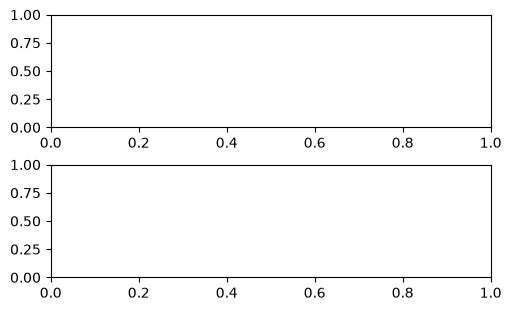

In [3]:
fig5, ax5= plt.subplots(nrows=2,figsize=(5,3), dpi=100, layout="constrained")

for i in range(0, M0.prototypes_.shape[0]):
    prot_group=pd.DataFrame(data=np.array([features,M0.prototypes_[i], M1.prototypes_[i], M2.prototypes_[i]
                                                                                      ]).T, 
                           columns=['features','M0','M1', 'M2'])#features)
    #prot_group.insert(0, 'Model', ['M0', 'M1', 'M2'])
    #ax5[i]
prot_group.set_index("features", inplace=True)
prot_group[['M0','M1', 'M2']]=prot_group[['M0','M1', 'M2']].astype('float64')
prot_group

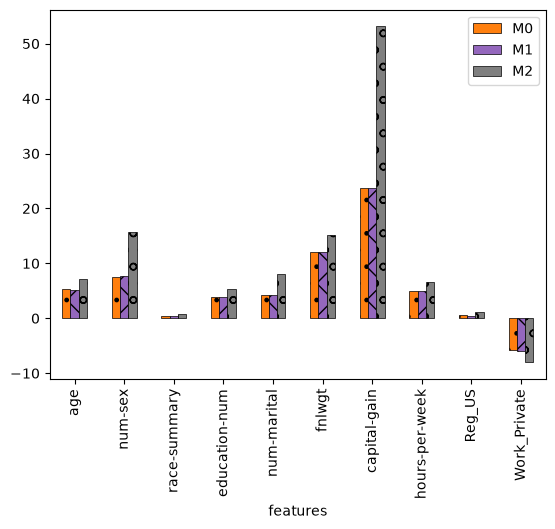

In [4]:
ax=prot_group.plot(kind='bar',# color=['orange', 'white','olive'], 
                   color=['tab:orange', 'tab:purple','tab:gray'], edgecolor=['k','k','k'],
                   linewidth=0.5,
                  # facecolor=['w', 'w','w'],
                   stacked=False)
bars = ax.patches
hatches = ''.join(h*len(prot_group) for h in '.xo')

for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

In [11]:
a=10.7
print(np.log(a))
print(np.exp(np.log(a)))
prot_group

2.3702437414678603
10.699999999999998


,M0,M1,M2
features,,,
age,5.330459,5.213754,7.096834
num-sex,7.526934,7.719582,15.792583
race-summary,0.494943,0.481475,0.812712
education-num,3.922803,3.890061,5.349282
num-marital,4.322308,4.171935,8.046422
fnlwgt,12.053274,12.031404,15.113455
capital-gain,23.710553,23.663593,53.124628
hours-per-week,5.052139,5.059878,6.652512
Reg_US,0.553529,0.489639,1.152925


0 0
1 1


/tmp/ipykernel_49659/249549592.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


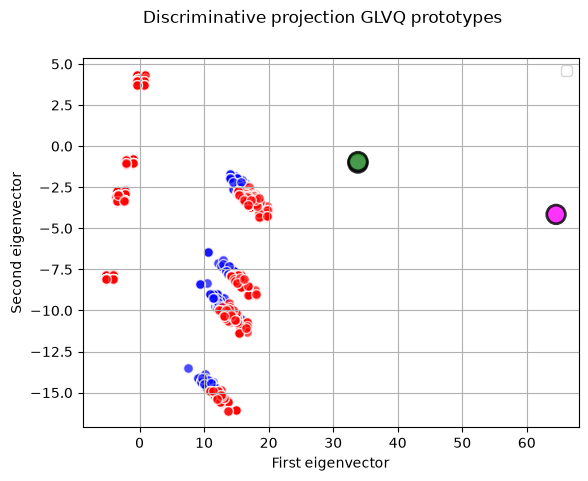

In [36]:
from sklearn.decomposition import PCA

prot_group2=pd.DataFrame(data=np.array([M0.prototypes_[i], M1.prototypes_[i], M2.prototypes_[i]]), 
                           columns=features)
pca_X=PCA(n_components=2).fit(zXtrain[features])
pc_prots_df=pca_X.transform(prot_group2)
pc_retrain_df=pca_X.transform(zXtrain[features])
labels=Ytrain#[unlearn_indices]
x_m =pc_prots_df[:, 0]
y_m = pc_prots_df[:, 1]

x_d = pc_retrain_df[:, 0]
y_d = pc_retrain_df[:, 1]

# Plot
fig, ax = plt.subplots()
fig.suptitle("Discriminative projection GLVQ prototypes")
colors = ["blue", "red", "green"]
for i, cls in enumerate(M0.classes_):
    print(i, cls)
    ii = cls == labels
    ax.scatter(
        x_d[ii],
        y_d[ii],
        c=colors[i],
        s=50,
        alpha=0.7,
        edgecolors="white",
       # label=iris.target_names[M0.prototypes_labels_[i]],
    )
colors2=['tab:purple','tab:green', 'magenta']
ax.scatter(x_m, y_m, c=colors2, s=180, alpha=0.8, edgecolors="black", linewidth=2.0)
ax.set_xlabel("First eigenvector")
ax.set_ylabel("Second eigenvector")
ax.legend()
ax.grid(True)

In [35]:
print(np.shape(labels), np.shape(x_m), np.shape(x_d))
M0.classes_

(32561,) (3,) (32561,)


array([0, 1])

In [33]:
x_m

array([33.8298805 , 33.84450169, 64.53267301])